Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 1.1060307046733147e-08
       x: [ 9.336e+00  5.394e+01]
     nit: 9
     jac: [-6.174e-05  3.669e-05]
    nfev: 27
    njev: 9
Instantaneous velocity at contact point: 7.435880253753109 m/s


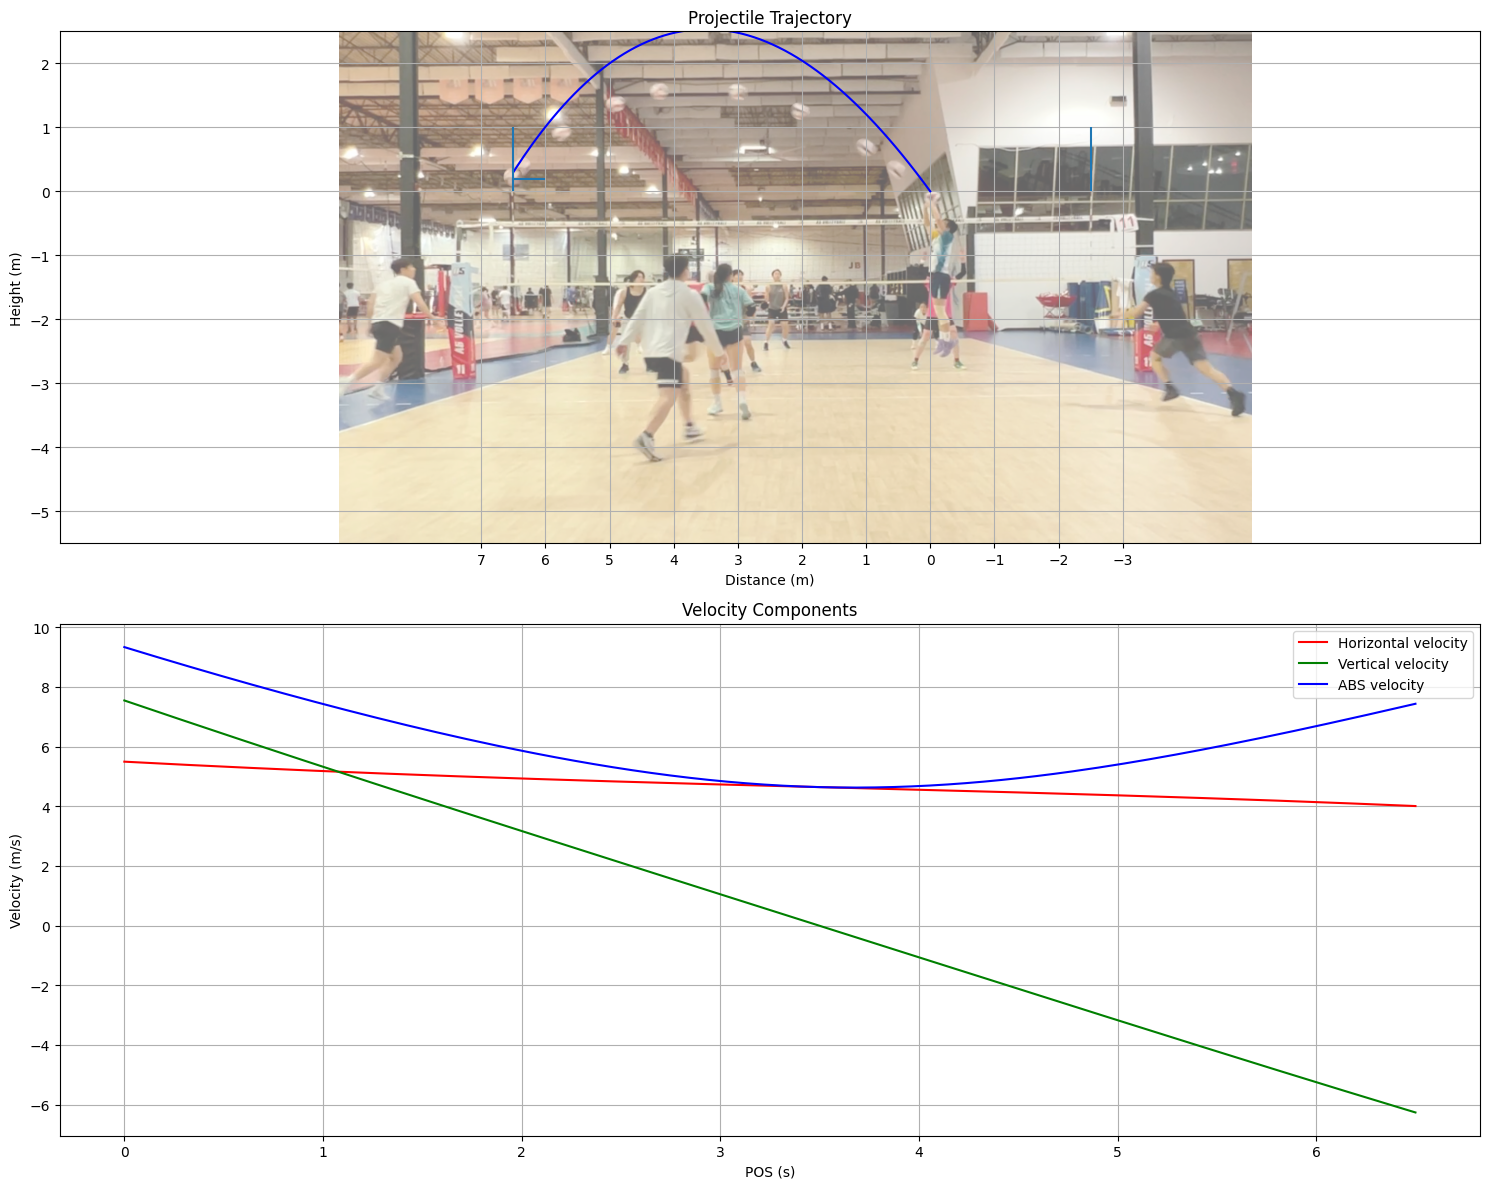

In [175]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize


def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

class ProjectileMotion:
    def __init__(self, 
                 mass=0.27,          # kg (volleyball mass)
                 diameter=0.21,       # m (volleyball diameter)
                 drag_coefficient=0.88, # dimensionless 0.48
                 air_density=1.225):  # kg/m³ (at sea level, 15°C)
        
        self.mass = mass
        self.diameter = diameter
        self.area = np.pi * (diameter/2)**2  # cross-sectional area
        self.drag_coefficient = drag_coefficient
        self.air_density = air_density
        self.gravity = 9.81  # m/s²
        
    def drag_force(self, velocity):
        """Calculate drag force using F = 1/2 * ρ * v² * Cd * A"""
        velocity_magnitude = np.linalg.norm(velocity)
        if velocity_magnitude == 0:
            return np.zeros_like(velocity)
        
        drag_magnitude = (0.5 * self.air_density * velocity_magnitude**2 * 
                         self.drag_coefficient * self.area)
        
        # Drag force acts in opposite direction of velocity
        return -drag_magnitude * velocity / velocity_magnitude
    
    def derivatives(self, state, t):
        """Calculate derivatives for position and velocity"""
        # state = [x, y, vx, vy]
        vx, vy = state[2], state[3]
        velocity = np.array([vx, vy])
        
        # Calculate drag force
        drag_force = self.drag_force(velocity)
        
        # Acceleration components (F = ma)
        ax = drag_force[0] / self.mass
        ay = drag_force[1] / self.mass - self.gravity
        
        return [vx, vy, ax, ay]
    
    def simulate(self, initial_velocity, angle_degrees, time_span, dt=0.01):
        """
        Simulate projectile motion
        
        Parameters:
        - initial_velocity: speed in m/s
        - angle_degrees: launch angle in degrees
        - time_span: simulation duration in seconds
        - dt: time step in seconds
        """
        # Convert angle to radians
        angle = np.deg2rad(angle_degrees)
        
        # Initial conditions [x, y, vx, vy]
        initial_state = [0, 0,
                        initial_velocity * np.cos(angle),
                        initial_velocity * np.sin(angle)]
        
        # Time points
        t = np.arange(0, time_span, dt)
        
        # Solve ODE
        solution = odeint(self.derivatives, initial_state, t)
        
        return t, solution
    
    def objective(self, params, x_target, y_target, time_span, dt=0.01):
        initial_velocity, angle_degrees = params
        angle = np.deg2rad(angle_degrees)
        
        x1, y1 = x_target, y_target

        initial_state = [0, 0,
                        initial_velocity * np.cos(angle),
                        initial_velocity * np.sin(angle)]
        
        t = np.arange(0, time_span, dt)

        solution = odeint(self.derivatives, initial_state, t)

        xT, yT = solution[-1][0], solution[-1][1]
        return (xT - x1)**2 + (yT - y1)**2  # squared distance error


    def find_objective(self, v0_guess, x_target, y_target, t):
        result = minimize(self.objective,
                        v0_guess,
                        args=(x_target, y_target, t),
                        method='SLSQP')
        return result

    def plot_trajectory(self, t, solution, show_velocity=True):
        """Plot the trajectory and optionally show velocity vectors"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
        # ax1 = plt.subplot()
        
        # Trajectory plot
        ax1.plot(solution[:, 0], solution[:, 1], 'b-', label='Trajectory')
        ax1.set_xlabel('Distance (m)')
        ax1.set_ylabel('Height (m)')
        ax1.set_title('Projectile Trajectory')
        ax1.grid(True)
        ax1.axis('equal')
        ax1.set_xlim([-3,8])
        ax1.set_xticks(range(-3, 8))
        ax1.vlines([-2.5, 6.5], 0, 1)
        ax1.hlines([0.2], 6, 6.5)
        ax1.invert_xaxis()
        img = plt.imread("Volleyball_Shoot_Processed.png")

        img_height = 8
        img_width = img_height*16/9

        img_pos = [-5, -5.5]

        ax1.imshow(img, extent=[img_pos[0]+img_width, img_pos[0], img_pos[1], img_pos[1]+img_height], alpha=0.6)
        
        # if show_velocity:
        #     # Plot velocity vectors at regular intervals
        #     skip = len(t) // 20  # Show ~20 vectors
        #     for i in range(0, len(t), skip):
        #         ax1.quiver(solution[i, 0], solution[i, 1],
        #                   solution[i, 2], solution[i, 3],
        #                   angles='xy', scale_units='xy', scale=50,
        #                   color='r', alpha=0.3)
        
        # Velocity components plot
        ax2.plot(solution[:, 0], solution[:, 2], 'r-', label='Horizontal velocity')
        ax2.plot(solution[:, 0], solution[:, 3], 'g-', label='Vertical velocity')
        ax2.plot(solution[:, 0], (abs(solution[:, 2])**2 + abs(solution[:, 3])**2)**0.5, 'b-', label='ABS velocity')
        ax2.set_xlabel('POS (s)')
        ax2.set_ylabel('Velocity (m/s)')
        ax2.set_title('Velocity Components')
        ax2.grid(True)
        ax2.legend()
        
        plt.tight_layout()
        # return fig# , (ax1, ax2)
        # return ax1
    
    def compare_with_ideal(self, initial_velocity, angle_degrees, time_span):
        """Compare with ideal projectile motion (no air resistance)"""
        # Simulate with air resistance
        t, solution_real = self.simulate(initial_velocity, angle_degrees, time_span)
        
        # Calculate ideal trajectory
        angle = np.deg2rad(angle_degrees)
        v0x = initial_velocity * np.cos(angle)
        v0y = initial_velocity * np.sin(angle)
        
        x_ideal = v0x * t
        y_ideal = v0y * t - 0.5 * self.gravity * t**2
        
        # Plot comparison
        plt.figure(figsize=(10, 6))
        plt.plot(solution_real[:, 0], solution_real[:, 1], 'b-', 
                label='With air resistance')
        plt.plot(x_ideal, y_ideal, 'r--', label='Ideal (no air resistance)')
        plt.xlabel('Distance (m)')
        plt.ylabel('Height (m)')
        plt.title('Comparison of Trajectories')
        plt.grid(True)
        plt.legend()
        plt.axis('equal')
        
        return t, solution_real, x_ideal, y_ideal

# Example usage
if __name__ == "__main__":
    # Create projectile instance (using volleyball properties)
    proj = ProjectileMotion(drag_coefficient = 0.48)
    
    # Cd = 0.48
    # rho = 1.225
    # A = 0.0346
    # m = 0.27

    time_span = 1.4

    result = proj.find_objective([10,40], 6.5, 0.3, time_span)
    print(result)

    initial_velocity, angle = result.x[0], result.x[1]
    # Run simulation
    t, solution = proj.simulate(initial_velocity, angle, time_span)
    # print(solution[-1])
    # print(solution[-1,2:4])
    print(f"Instantaneous velocity at contact point: {np.linalg.norm(solution[-1,2:4])} m/s")
    # idx = find_nearest(solution[:,0], 6.5)
    # print(solution[idx])
    proj.plot_trajectory(t, solution, show_velocity=True)

    # # Simulate a shot
    # initial_velocity = 9.15  # m/s
    # angle = 39.8           # degrees
    # time_span = 1.08        # seconds
    
    # # Run simulation
    # t, solution = proj.simulate(initial_velocity, angle, time_span)
    # print(solution[-1])
    # idx = find_nearest(solution[:,0], 6.5)
    # print(solution[idx])
    # proj.plot_trajectory(t, solution, show_velocity=True)


    # # Simulate a shot
    # initial_velocity = 9  # m/s
    # angle = 50           # degrees
    # time_span = 1.5        # seconds
    
    # # Run simulation
    # t, solution = proj.simulate(initial_velocity, angle, time_span)
    # print(solution[-1])
    # idx = find_nearest(solution[:,0], 6.5)
    # print(solution[idx])
    # proj.plot_trajectory(t, solution, show_velocity=True)
    
    # Compare with ideal projectile motion
    # proj.compare_with_ideal(initial_velocity, angle, time_span)
    
    # plt.show()